<a href="https://colab.research.google.com/github/Aarjav8055/ML-LAB/blob/main/LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# 1. Import Required Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ================================
# 2. Load Dataset
# ================================
# Ensure 'parkinsons.data' is uploaded to the Colab environment.
# If uploaded, it will typically be found in the /content/ directory.
df = pd.read_csv("/content/parkinsons.data")

print("First 5 Rows:")
print(df.head())

# ================================
# 3. Descriptive Statistics
# ================================
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nClass Distribution:")
print(df['status'].value_counts())

# ================================
# 4. Data Cleaning & Preprocessing
# ================================

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop 'name' column (not useful for prediction)
if 'name' in df.columns:
    df.drop(columns=['name'], inplace=True)

# Define features and target
X = df.drop("status", axis=1)
y = df["status"]

# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 6. Feature Scaling
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 7. Build Logistic Regression Model
# ================================
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)

# ================================
# 8. Model Prediction
# ================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ================================
# 9. Model Evaluation
# ================================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# ================================
# 10. ROC Curve Plot
# ================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/parkinsons.data'

In [ ]:
import os
print(os.listdir("/content"))



['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()



Saving parkinsons.data to parkinsons.data


In [ ]:
df = pd.read_csv("parkinsons.data")



In [ ]:
# =========================================
# Import Libraries
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# =========================================
# Load Dataset
# =========================================
df = pd.read_csv("/content/parkinsons.data")

# Drop name column
df.drop("name", axis=1, inplace=True)

# =========================================
# -------- Linear Regression --------
# =========================================
X_reg = df.drop("PPE", axis=1)
y_reg = df["PPE"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_reg = lin_model.predict(X_test)

print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_reg))
print("R2 Score:", r2_score(y_test, y_pred_reg))


# =========================================
# -------- Logistic Regression --------
# =========================================
X_cls = df.drop("status", axis=1)
y_cls = df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

y_pred_cls = log_model.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_cls))


First 5 Rows:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \

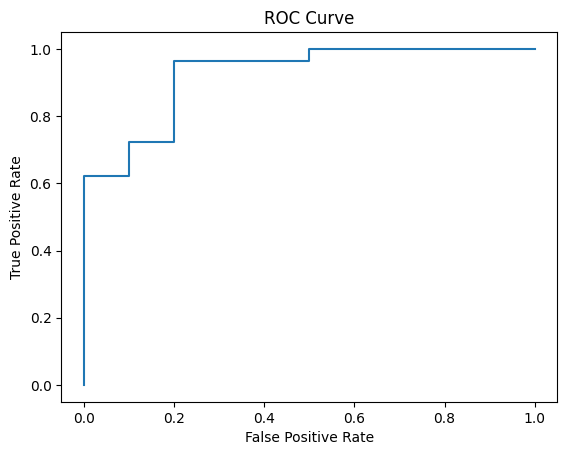

In [2]:
# ================================
# 1. Import Required Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv("/content/parkinsons.data")

print("First 5 Rows:")
print(df.head())

# ================================
# 3. Descriptive Statistics
# ================================
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nClass Distribution:")
print(df['status'].value_counts())

# ================================
# 4. Data Cleaning & Preprocessing
# ================================

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop 'name' column (not useful for prediction)
if 'name' in df.columns:
    df.drop(columns=['name'], inplace=True)

# Define features and target
X = df.drop("status", axis=1)
y = df["status"]

# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 6. Feature Scaling
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 7. Build Logistic Regression Model
# ================================
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)

# ================================
# 8. Model Prediction
# ================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ================================
# 9. Model Evaluation
# ================================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# ================================
# 10. ROC Curve Plot
# ================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()